--- Conflict Report ---
Repos with ≥1 conflict: 2 | Total conflicts: 0
Repos with ≥5 conflicts: 1

--- Company-wise Conflict Report ---
google: Attempts (repos) = 7 | Repos with ≥1 conflict = 1 | Repos with ≥5 conflicts = 0 | Total conflicts = 0
microsoft: Attempts (repos) = 43 | Repos with ≥1 conflict = 1 | Repos with ≥5 conflicts = 1 | Total conflicts = 0


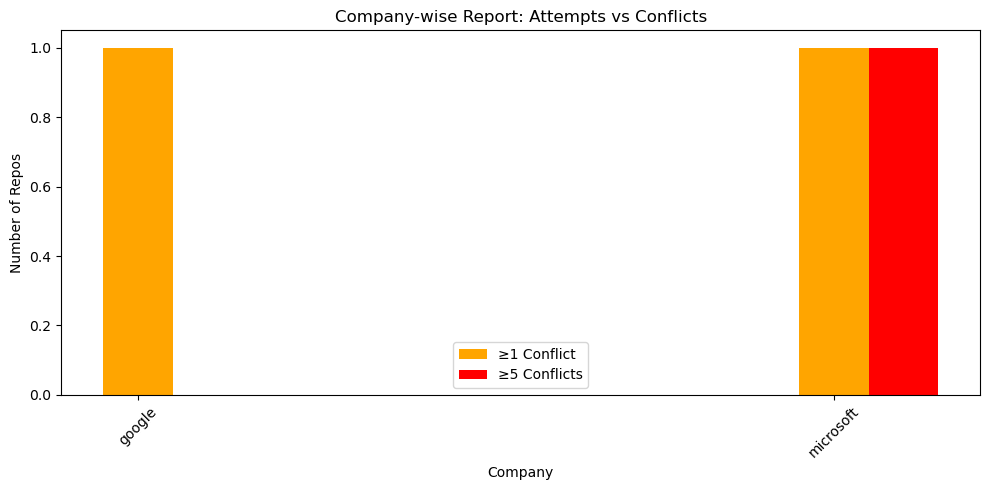

In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict
from db_operations import get_db_conn

conn = get_db_conn()
cur = conn.cursor()

# Get processed repos per company (aka "attempts")
cur.execute("""
    SELECT LOWER(organization), COUNT(*) 
    FROM searchrepos 
    WHERE is_active = FALSE 
    GROUP BY LOWER(organization);
""")
company_attempts = {row[0]: row[1] for row in cur.fetchall()}

# Get all repos with conflicts >= 1
cur.execute("""
    SELECT LOWER(organization), COUNT(*), SUM(license_conflicts)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 1
    GROUP BY LOWER(organization);
""")
company_conflict_1plus = {row[0]: row[1] for row in cur.fetchall()}
company_total_conflicts = {row[0]: row[2] for row in cur.fetchall()}

# Get all repos with conflicts >= 5
cur.execute("""
    SELECT LOWER(organization), COUNT(*)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 5
    GROUP BY LOWER(organization);
""")
company_conflict_5plus = {row[0]: row[1] for row in cur.fetchall()}

cur.close()
conn.close()

# Aggregated counts
repos_1plus = sum(company_conflict_1plus.values())
repos_5plus = sum(company_conflict_5plus.values())
total_conflict_1plus = sum(company_total_conflicts.get(org, 0) for org in company_conflict_1plus)

# total_conflict_5plus isn't precomputed, but you can fetch that if needed separately.

# Print results
print(f"--- Conflict Report ---")
print(f"Repos with ≥1 conflict: {repos_1plus} | Total conflicts: {total_conflict_1plus}")
print(f"Repos with ≥5 conflicts: {repos_5plus}")

companies = sorted(set(company_attempts) | set(company_conflict_1plus) | set(company_conflict_5plus))

print(f"\n--- Company-wise Conflict Report ---")
for company in companies:
    attempts = company_attempts.get(company, 0)
    c1 = company_conflict_1plus.get(company, 0)
    c5 = company_conflict_5plus.get(company, 0)
    total_conflicts = company_total_conflicts.get(company, 0)
    print(f"{company}: Attempts (repos) = {attempts} | Repos with ≥1 conflict = {c1} | Repos with ≥5 conflicts = {c5} | Total conflicts = {total_conflicts}")

# Visualization
x = range(len(companies))
width = 0.1
repos_1plus_counts = [company_conflict_1plus.get(c, 0) for c in companies]
repos_5plus_counts = [company_conflict_5plus.get(c, 0) for c in companies]
attempt_counts = [company_attempts.get(c, 0) for c in companies]

plt.figure(figsize=(10, 5))
# plt.bar([i - width for i in x], attempt_counts, width=width, label='Attempts Made', color='gray')
plt.bar(x, repos_1plus_counts, width=width, label='≥1 Conflict', color='orange')
plt.bar([i + width for i in x], repos_5plus_counts, width=width, label='≥5 Conflicts', color='red')

plt.xlabel('Company')
plt.ylabel('Number of Repos')
plt.title('Company-wise Report: Attempts vs Conflicts')
plt.xticks(x, companies, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

--- Conflict Report ---
Repos with ≥1 conflict: 180 | Total conflicts: 5169
Repos with ≥5 conflicts: 69 | Total conflicts: 5010

--- Company-wise Conflict Report ---
google: Attempts (repos) = 2145 | Repos with ≥1 conflict = 97 | Repos with ≥5 conflicts = 38 | Total conflicts (methods) = 3809
microsoft: Attempts (repos) = 2114 | Repos with ≥1 conflict = 83 | Repos with ≥5 conflicts = 31 | Total conflicts (methods) = 1360


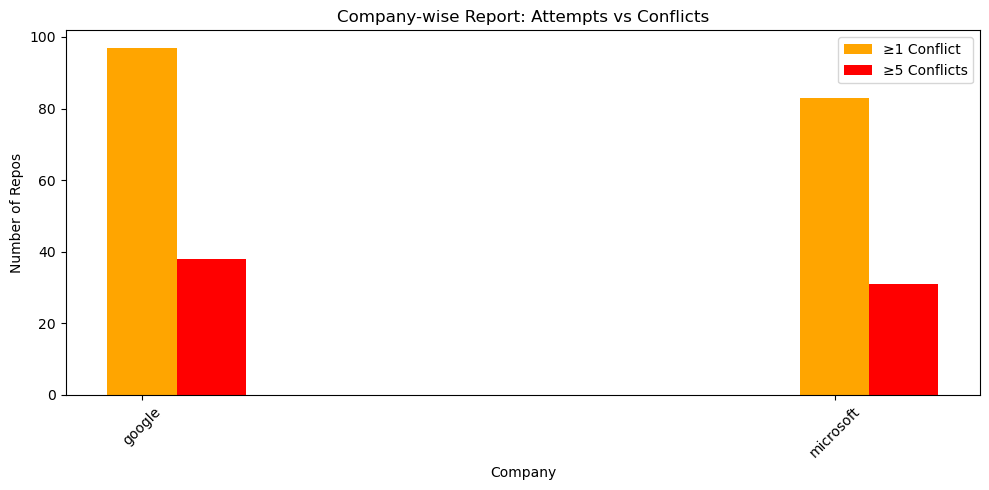

In [ ]:
'''
import os
import glob
import matplotlib.pyplot as plt
from collections import defaultdict
from db_operations import get_db_conn

# Directory containing CSV files
RESULTS_FOLDER = "../shell_scripts/results"

conn = get_db_conn()
cur = conn.cursor()

# Execute the query
cur.execute("""SELECT organization, COUNT(*) FROM searchrepos WHERE is_active = FALSE GROUP BY organization;""")

# Fetch results into a dict
company_attempts = {row[0].lower(): row[1] for row in cur.fetchall()}

cur.close()
conn.close()

# Get all CSV files in the results folder
csv_files = glob.glob(os.path.join(RESULTS_FOLDER, "*.csv"))

# Counters
total_conflict_1plus = 0
total_conflict_5plus = 0
repos_1plus = 0
repos_5plus = 0
company_total_conflicts = defaultdict(int)
# Per-company data
company_conflict_1plus = defaultdict(int)
company_conflict_5plus = defaultdict(int)

for file in csv_files:
    filename = os.path.basename(file)
    parts = filename.split('_')
    
    company = parts[0]
    num_conflict = int(parts[-1].split('.')[0])
    company_total_conflicts[company] += num_conflict
    
    if num_conflict >= 1:
        repos_1plus += 1
        total_conflict_1plus += num_conflict
        company_conflict_1plus[company] += 1
    
    if num_conflict >= 5:
        repos_5plus += 1
        total_conflict_5plus += num_conflict
        company_conflict_5plus[company] += 1

# Print results
print(f"--- Conflict Report ---")
print(f"Repos with ≥1 conflict: {repos_1plus} | Total conflicts: {total_conflict_1plus}")
print(f"Repos with ≥5 conflicts: {repos_5plus} | Total conflicts: {total_conflict_5plus}")

companies = sorted(set(company_conflict_1plus.keys())
                   .union(company_conflict_5plus.keys())
                   .union(company_attempts.keys()))

print(f"\n--- Company-wise Conflict Report ---")
for company in sorted(companies):
    attempts = company_attempts.get(company, 0)
    c1 = company_conflict_1plus.get(company, 0)
    c5 = company_conflict_5plus.get(company, 0)
    total_conflicts = company_total_conflicts.get(company, 0)
    print(f"{company}: Attempts (repos) = {attempts} | Repos with ≥1 conflict = {c1} | Repos with ≥5 conflicts = {c5} | Total conflicts (methods) = {total_conflicts}")

repos_1plus_counts = [company_conflict_1plus.get(c, 0) for c in companies]
repos_5plus_counts = [company_conflict_5plus.get(c, 0) for c in companies]
attempt_counts = [company_attempts.get(c, 0) for c in companies]

x = range(len(companies))
width = 0.1

plt.figure(figsize=(10, 5))
#plt.bar([i - width for i in x], attempt_counts, width=width, label='Attempts Made', color='gray')
plt.bar(x, repos_1plus_counts, width=width, label='≥1 Conflict', color='orange')
plt.bar([i + width for i in x], repos_5plus_counts, width=width, label='≥5 Conflicts', color='red')

plt.xlabel('Company')
plt.ylabel('Number of Repos')
plt.title('Company-wise Report: Attempts vs Conflicts')
plt.xticks(x, companies, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
'''

In [ ]:
'''
### Count number of repos with incompatible licenses

import os
import glob

# Directory containing CSV files
RESULTS_FOLDER = "../shell_scripts/results"

# Get all CSV files in the results folder
csv_files = glob.glob(os.path.join(RESULTS_FOLDER, "*.csv"))

total_file = 0
total_conflict = 0

for file in csv_files:

    company = file.split('_')[0]
    
    num_conflict = int(file.split('_')[-1].split('.')[0])
    if num_conflict >= 1:
        print(f"Reading {file}")
        total_file = total_file+1
        total_conflict += num_conflict

print(f"Number of unique repos with at least one conflict: {total_file}\nTotal number of conflicting methods: {total_conflict}")

'''

In [ ]:
'''
import os
import glob
import psycopg2
import pandas as pd
from psycopg2.extras import execute_values

# Database connection details
DB_NAME = "github_repos"
DB_USER = "postgres"
DB_PASSWORD = "Sphings@19"
DB_HOST = "localhost"
DB_PORT = "5432"

# Directory containing CSV files
RESULTS_FOLDER = "../results"

try:
    # Connect to PostgreSQL
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    cur = conn.cursor()

    # Get all CSV files in the results folder
    csv_files = glob.glob(os.path.join(RESULTS_FOLDER, "*.csv"))

    # Read and combine all CSV files into a single DataFrame
    all_data = pd.DataFrame()

    for file in csv_files:
        print(f"Reading {file}...")
        df = pd.read_csv(file)

        # Rename CSV columns to match the database
        df.rename(columns={
            'Hash': 'hash',
            'Project ID': 'project_id',
            'Version': 'version',
            'License': 'license',
            'Method Name': 'method_name',
            'File Location': 'file_location',
            'Function Code': 'function_code',
            'Repository URL': 'repository_url',
            'Query Project': 'query_project',
            'Violation': 'violation',
            'Source_project': 'Source_project',
            'Source_project_version':'Source_project_version'
        }, inplace=True)

        all_data = pd.concat([all_data, df], ignore_index=True)

    # Remove duplicates based on (hash, project_id)
    all_data.drop_duplicates(subset=['hash', 'project_id'], inplace=True)

    # Generate unique ID by combining hash and project_id
    all_data['_id'] = all_data['hash'].astype(str) + "_" + all_data['project_id'].astype(str)

    # Convert DataFrame to a list of tuples for batch insert
    records_to_insert = [
        (
            row['_id'], row['hash'], row['project_id'], row['version'], row['license'], row['method_name'],
            row['file_location'], row['function_code'], row['repository_url'], row['query_project'], row['violation'],
            row['Source_project'],row['Source_project_version']
        ) for _, row in all_data.iterrows()
    ]

    # Insert all records in bulk
    insert_query = """
     INSERT INTO repository_data (
        _id, hash, project_id, version, license, method_name,
        file_location, function_code, repository_url, query_project, violation, Source_project, Source_project_version
    ) VALUES %s
    ON CONFLICT (hash, project_id, version) DO NOTHING;
    """
    
    
    execute_values(cur, insert_query, records_to_insert)

    # Commit changes
    conn.commit()
    print(f"Inserted {len(records_to_insert)} new records successfully.")

except Exception as e:
    print("Error:", e)

finally:
    # Close connection
    if conn:
        cur.close()
        conn.close()
'''